# Excitation Cell drift over time

In [19]:
from modules import *
from functions import *

### Setup initial receptive fields

In [6]:
N = int(500)                   # Number of neurons
a = 10                         # Propensity parameter (for tanh(a*w))
x_stim = 0.5                   # POSITION to stimulate at during deprivation (in [0, L])
n_test_positions = 100         # Number of x-samples to test preferred position
L = 1.0                        # Track length (choose units: meters or bins)

rng = np.random.default_rng(0)
vars = np.random.lognormal(np.log(0.05 * L), 0.6, size=N)      

learning_rate = 1e-2

n_days = 28
n_norm_per_day = 1
n_steps_per_norm = 30
n_steps = n_steps_per_norm * n_norm_per_day * n_days
init_steps = 300 

hebb_scaling = 0.3
rand_scaling = 1.0

# --- Initialise weights with NON-WRAPPED place fields ---
W_init = initialise_W(N, vars, L=L)   # uses place_matrix_different_vars under the hood

# --- Short baseline prerun with position inputs (baseline sampling) ---
W_baseline = prerun(
    W_init, x_stim, a,
    hebb_scaling, rand_scaling, learning_rate,
    n_steps_per_norm, init_steps, L=L
)

# --- Allocate arrays (same shape) ---
W = np.zeros((N, N, n_steps + 1))
W[:, :, 0] = W_baseline
W_per_day = np.zeros((N, N, n_days))

PPs = [ get_preferred_positions(N, W_per_day[:, :, d], n_positions=n_test_positions, L=L)
        for d in range(n_days) ]



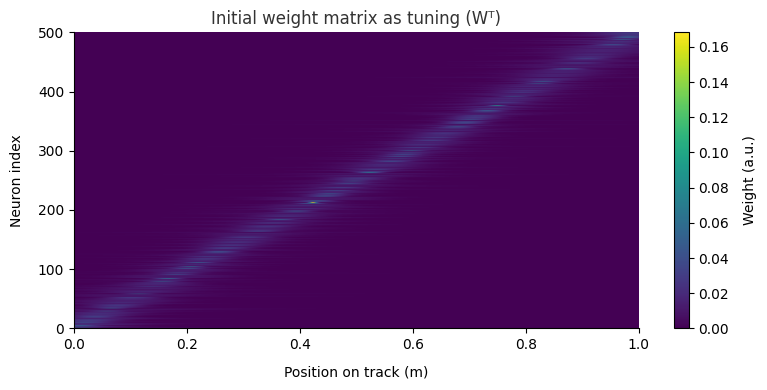

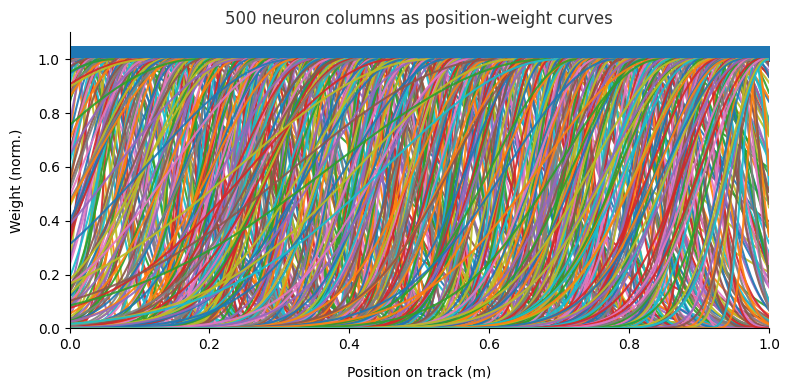

In [7]:
def plot_W_init_heatmap(W, L=1.0, title="Weight matrix as tuning (Wᵀ)"):
    """
    Show W^T as a neuron × position heatmap so the x-axis is position (m),
    y-axis is neuron index, like your previous population heatmap.
    """
    M_inputs, N_neurons = W.shape  # current code: N×N, but works for M×N too
    x = np.linspace(0.0, L, M_inputs)

    plt.figure(figsize=(8, 4))
    # transpose so rows = neurons, columns = positions
    plt.imshow(W.T, aspect='auto', origin='lower',
               extent=[x[0], x[-1], 0, N_neurons])
    plt.colorbar(label="Weight (a.u.)")
    plt.xlabel("Position on track (m)")
    plt.ylabel("Neuron index")
    plt.title(title)
    plt.tight_layout()
    plt.show()

def plot_W_init_columns_as_curves(W, L=1.0, max_curves=20, normalize_each=True):
    """
    Plot a subset of neuron columns as curves over position (like tuning curves).
    Each curve is one column W[:, i] vs position. Optionally normalize each
    curve to its own max for readability.
    """
    M_inputs, N_neurons = W.shape
    x = np.linspace(0.0, L, M_inputs)
    k = min(max_curves, N_neurons)

    plt.figure(figsize=(8, 4))
    for i in range(k):
        y = W[:, i]
        if normalize_each and y.max() > 0:
            y = y / y.max()
        plt.plot(x, y, alpha=0.9)
    # mark approximate centers (argmax of each shown column)
    centers_idx = np.argmax(W[:, :k], axis=0)
    centers_x = x[centers_idx]
    plt.scatter(centers_x, np.ones(k)*1.02, marker='|', s=120)
    plt.ylim(0, 1.1 if normalize_each else None)
    plt.xlabel("Position on track (m)")
    plt.ylabel("Weight" + (" (norm.)" if normalize_each else " (a.u.)"))
    plt.title(f"{k} neuron columns as position-weight curves")
    plt.tight_layout()
    plt.show()

plot_W_init_heatmap(W_init, L=L, title="Initial weight matrix as tuning (Wᵀ)")
plot_W_init_columns_as_curves(W_init, L=L, max_curves=500)


### Setup the excitability curves

In [71]:
def show_matrix(M, title="Matrix", xlabel="X", ylabel="Y", cmap="viridis"):
    """
    Quick display of a 2D matrix using imshow.
    Automatically handles numpy arrays and lists-of-lists.
    """
    M = np.asarray(M)

    plt.figure(figsize=(6, 4))
    im = plt.imshow(M, aspect='auto', interpolation='nearest', cmap=cmap)
    plt.colorbar(im)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()


def plot_exc_traces(exc, n_traces=100, alpha=0.05, linewidth=1.0,
                    title="Neuron Excitability Over Time",
                    xlabel="Time (hours)", ylabel="Excitability"):
    """
    Plots excitability traces for a set of neurons.
    
    Parameters:
        exc : 2D array (N neurons × T timepoints)
        n_traces : number of randomly selected neurons to plot
        alpha : transparency for each line (0-1)
        linewidth : width of each neuron trace
    """
    exc = np.asarray(exc)
    N, T = exc.shape

    # Select subset to prevent over-plotting
    if n_traces < N:
        idx = np.random.choice(N, size=n_traces, replace=False)
        data = exc[idx, :]
    else:
        data = exc

    time_axis = np.arange(T)

    plt.figure(figsize=(10, 5))

    for trace in data:
        plt.plot(time_axis, trace, alpha=alpha, linewidth=linewidth, color='black')

    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()

def plot_series(y, x=None, title="Series Plot", xlabel="Index", ylabel="Value", lw=2, alpha=1.0):
    """
    Plot a single 1D variable list or array.
    
    Args:
        y: list or 1D numpy array of values to plot
        x: optional x-axis values (same length as y). If None, uses index.
        title, xlabel, ylabel: labels for plot
        lw: line width
        alpha: line transparency
    """
    import numpy as np
    import matplotlib.pyplot as plt

    y = np.asarray(y)
    
    if x is None:
        x = np.arange(len(y))
    
    plt.figure(figsize=(6, 3.2))
    plt.plot(x, y, linewidth=lw, alpha=alpha)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.tight_layout()
    plt.show()


0
0 100 0 168
168
100 200 168 336
336
200 300 336 504
504
300 400 504 672
672
400 500 672 840
840
500 600 840 1008
(500, 840)


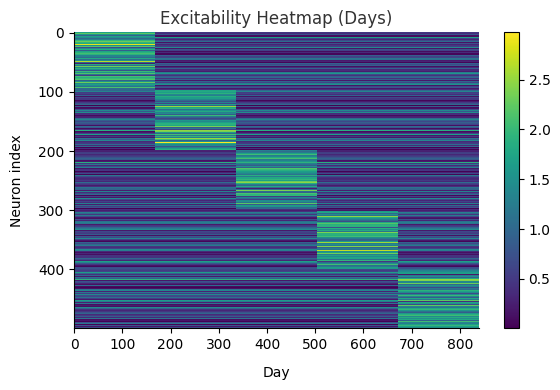

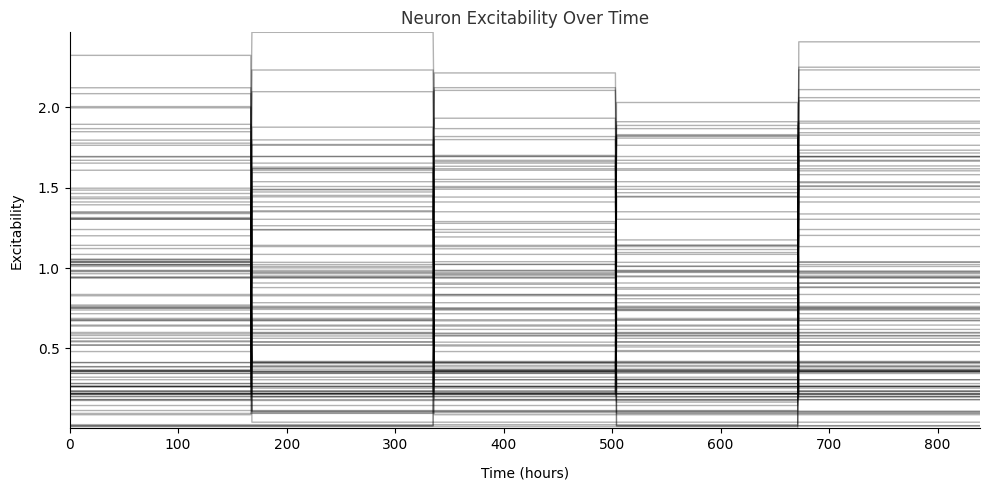

In [116]:
# --- Excitability schedule across days ---
# Uses circadian rhythm + slow cell-by-cell drift + spatial bump near x_stim

A = 0.6          # circadian amplitude
sigma = 0.15     # neuron-specific drift strength
alpha = 0.995    # temporal smoothness (higher = slower drift)

# Preferred positions for each neuron (same as used in your place fields)
positions = np.linspace(0, L, N, endpoint=False)

# Width of excitability bump (in track units)
bump_width = 0.12 * L   

exc = np.zeros((N, n_steps))

# Initial random neuron-specific offset
delta = rng.normal(0, sigma, size=N)

# for d in range(n_days):
#     # Circadian term: assume each "day" corresponds to a full 24h cycle
#     circ = A * np.sin(2 * np.pi * (d % 24) / 24.0 + d)
#     # Spatial excitability bump centered at x_stim
#     dist = np.abs(positions - x_stim)
#     dist = np.minimum(dist, L - dist)      # wrap around track
#     bump = np.exp(-0.5 * (dist / bump_width)**2)

#     # Combine: baseline + circadian + neuron-specific drift + bump
#     exc[:, d] = circ + delta + bump

#     # Update neuron-specific drift each day (slow wandering bias)
#     delta = alpha * delta + (1 - alpha) * rng.normal(0, sigma, size=N)

exc_baseline = abs(np.random.normal(0.5, 0.5, size=(N, 1)))
exc = np.tile(exc_baseline, (1, n_steps))
exc_elevated = abs(np.random.normal(1.5, 0.5, size=(N, 1)))
exc_elevated = np.tile(exc_elevated, (1, n_steps))
devs = 5
for i in range(0,devs+1):
    #print(i*N//devs)
    print(i* n_steps//(devs))
    start_N  = i*N//devs
    end_N = (i+1)* N//devs
    start_n =  i* n_steps//(devs)
    end_n = (i+1)* n_steps//(devs)
    print(start_N, end_N, start_n, end_n)
    exc[start_N:end_N, start_n:end_n] = exc_elevated[start_N:end_N, start_n:end_n]

print(np.shape(exc))
#exc[499:, :]
# Visualize
show_matrix(exc, title="Excitability Heatmap (Days)", xlabel="Day", ylabel="Neuron index")
plot_exc_traces(exc, n_traces=120, alpha=0.30) #0.08
